In [2]:
import numpy as np

data = np.load('./olivetti_faces.npy')
target = np.load('./olivetti_faces_target.npy')

In [ ]:
# 40명의 사람들마다 10개의 표정
print("There are " + str(len(data)) + " images in the dataset")
print("There are " +  str(len(np.unique(target))) + " unique targets in the dataset")

There are 400 images in the dataset
There are 40 unique targets in the dataset


In [4]:
print("unique target number:" + str(np.unique(target)))

unique target number:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


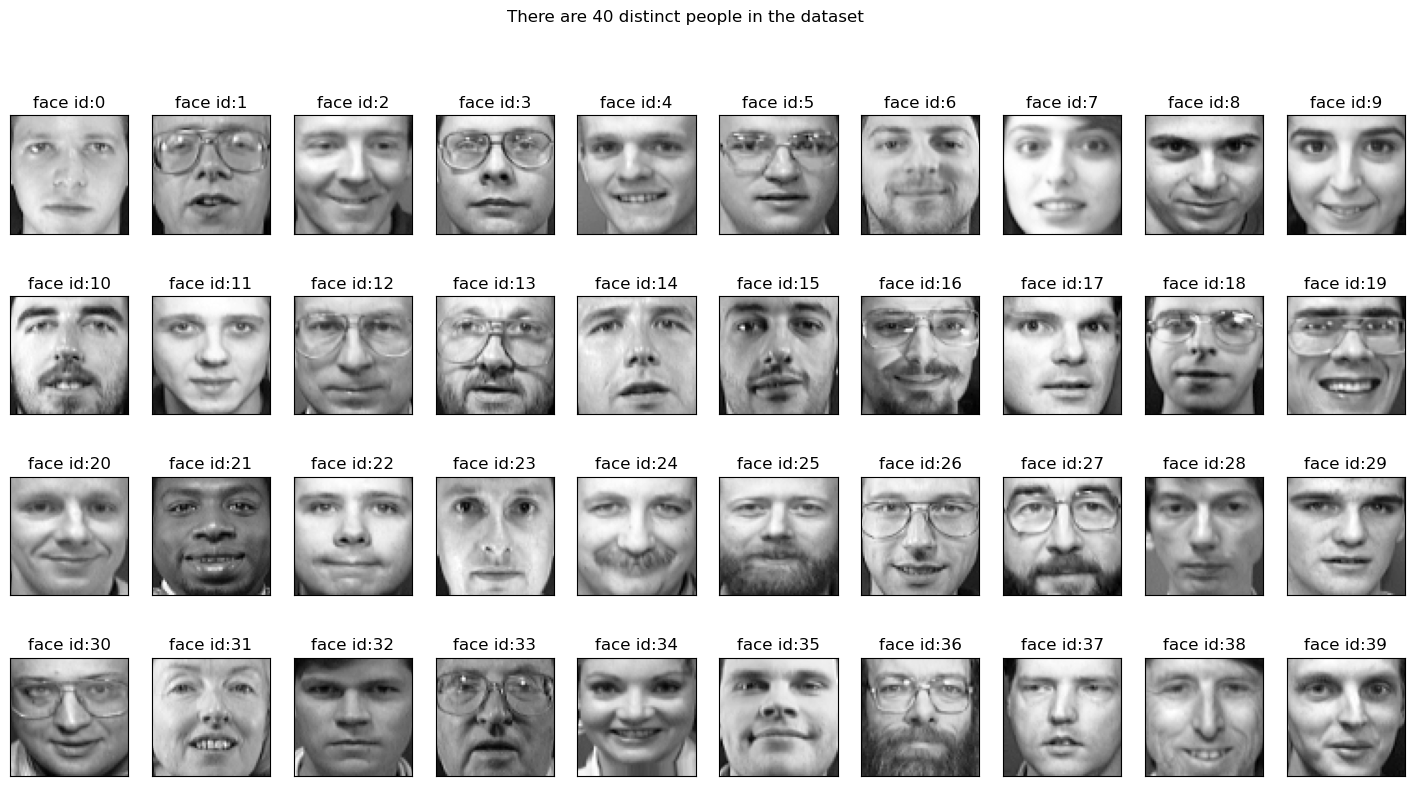

In [5]:
# 데이터 시각화
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=4,
                       ncols=10,
                       figsize=(18, 9))
ax = ax.flatten()

unique_ids = np.unique(target)
for unique_id in unique_ids:
    image_idx = unique_id * 10
    ax[unique_id].imshow(data[image_idx], cmap='gray')
    ax[unique_id].set_xticks([])
    ax[unique_id].set_yticks([])
    ax[unique_id].set_title("face id:{}".format(unique_id))
plt.suptitle("There are 40 distinct people in the dataset")

plt.show()

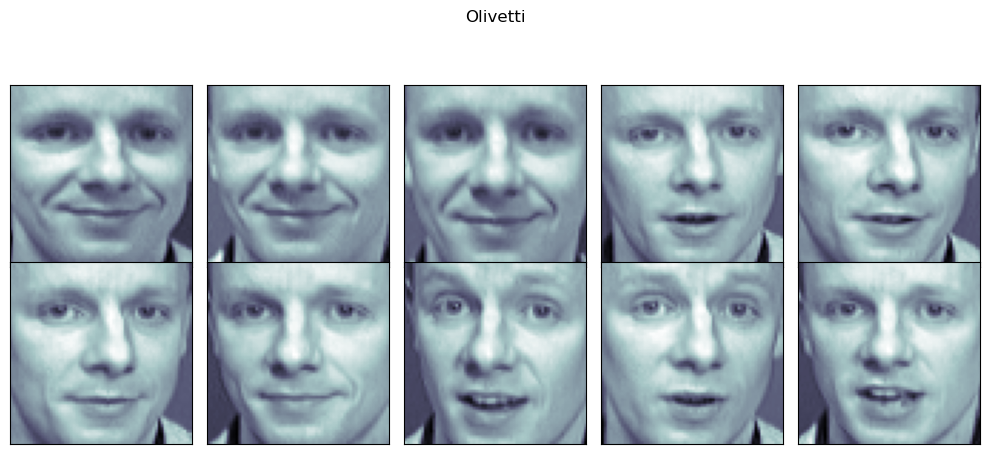

In [6]:
# 한명만 골라서 PCA
id = 20
faces = data[target == id]

n = 2
m = 5

fig = plt.figure(figsize=(10, 5))
plt.subplots_adjust(top=1,
                    bottom=0,
                    hspace=0,
                    wspace=0.05)
for i in range(n * m):
    ax = fig.add_subplot(n, m, i + 1)
    ax.imshow(faces[i], cmap=plt.cm.bone)
    ax.grid(False)
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])

plt.suptitle('Olivetti')

plt.tight_layout()
plt.show()

In [ ]:
# 주성분 2개로 축소
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x = data[target == id]
n_samples, n_rows, n_columns = x.shape

x_flat = x.reshape(n_samples, n_rows * n_columns)
w = pca.fit_transform(x_flat)

x_inv = pca.inverse_transform(w)

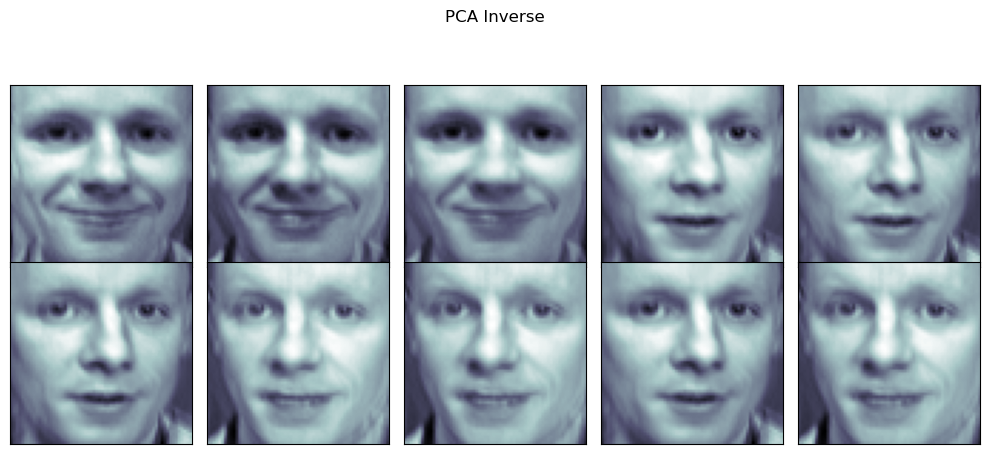

In [13]:
# 역변환 결과
n = 2
m = 5

fig = plt.figure(figsize=(10, 5))
plt.subplots_adjust(top=1,
                    bottom=0,
                    hspace=0,
                    wspace=0.05)
for i in range(n * m):
    ax = fig.add_subplot(n, m, i + 1)
    ax.imshow(x_inv[i].reshape(64, 64), cmap=plt.cm.bone)
    ax.grid(False)
    ax.xaxis.set_ticks([])
    ax.yaxis.set_ticks([])

plt.suptitle('PCA Inverse')

plt.tight_layout()
plt.show()

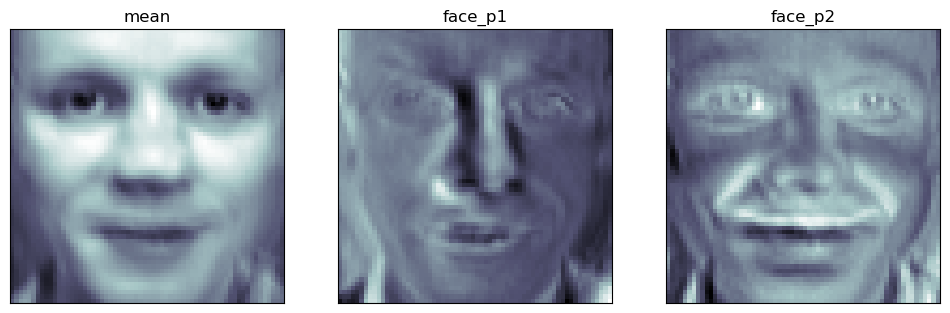

In [ ]:
# 두 벡터의 평균과 벡터 시각화
face_mean = pca.mean_.reshape(64, 64)

face_p1 = pca.components_[0].reshape(64, 64)
face_p2 = pca.components_[1].reshape(64, 64)

plt.figure(figsize=(12, 7))

plt.subplot(131)
plt.imshow(face_mean, cmap=plt.cm.bone)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title('mean')

plt.subplot(132)
plt.imshow(face_p1, cmap=plt.cm.bone)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title('face_p1')

plt.subplot(133)
plt.imshow(face_p2, cmap=plt.cm.bone)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.title('face_p2')

plt.show()

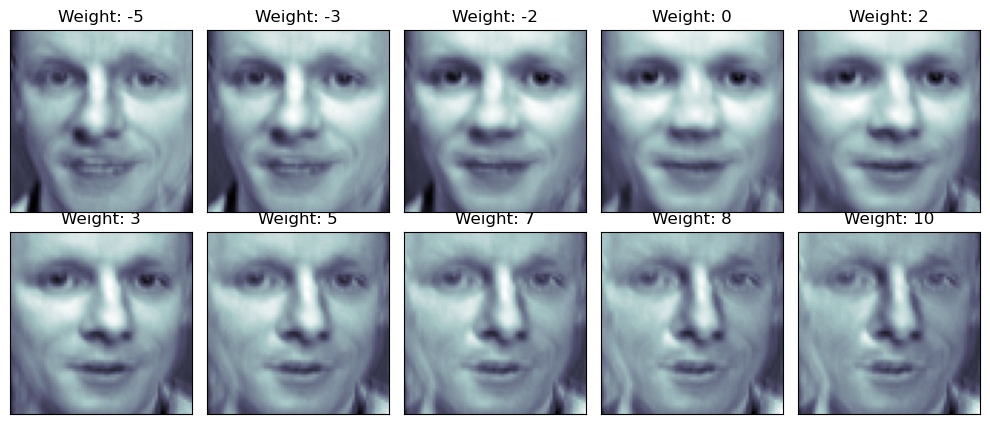

In [ ]:
# 1번 주성분의 변화에 따른 평균의 변화
w = np.linspace(-5, 10, n * m)

fig = plt.figure(figsize=(10, 5))
plt.subplots_adjust(top=1,
                    bottom=0,
                    hspace=0,
                    wspace=0.05)
for i in range(n * m):
    ax = fig.add_subplot(n, m, i + 1)
    ax.imshow(face_mean + w[i] * face_p1, cmap=plt.cm.bone)
    ax.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Weight: {round(w[i])}')

plt.tight_layout()
plt.show()

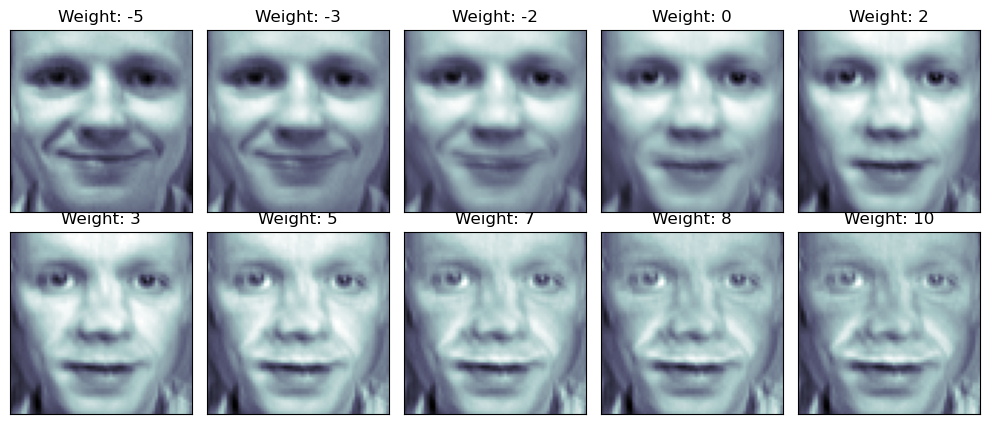

In [17]:
# 2번 주성분의 변화에 따른 평균의 변화
w = np.linspace(-5, 10, n * m)

fig = plt.figure(figsize=(10, 5))
plt.subplots_adjust(top=1,
                    bottom=0,
                    hspace=0,
                    wspace=0.05)
for i in range(n * m):
    ax = fig.add_subplot(n, m, i + 1)
    ax.imshow(face_mean + w[i] * face_p2, cmap=plt.cm.bone)
    ax.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Weight: {round(w[i])}')

plt.tight_layout()
plt.show()

In [18]:
# 1, 2번 주성분의 변화에 따른 평균의 변화
nx, ny = 5, 5

x = np.linspace(-5, 8, nx)
y = np.linspace(-5, 8, ny)
w1, w2 = np.meshgrid(x, y)
w1, w2

(array([[-5.  , -1.75,  1.5 ,  4.75,  8.  ],
        [-5.  , -1.75,  1.5 ,  4.75,  8.  ],
        [-5.  , -1.75,  1.5 ,  4.75,  8.  ],
        [-5.  , -1.75,  1.5 ,  4.75,  8.  ],
        [-5.  , -1.75,  1.5 ,  4.75,  8.  ]]),
 array([[-5.  , -5.  , -5.  , -5.  , -5.  ],
        [-1.75, -1.75, -1.75, -1.75, -1.75],
        [ 1.5 ,  1.5 ,  1.5 ,  1.5 ,  1.5 ],
        [ 4.75,  4.75,  4.75,  4.75,  4.75],
        [ 8.  ,  8.  ,  8.  ,  8.  ,  8.  ]]))

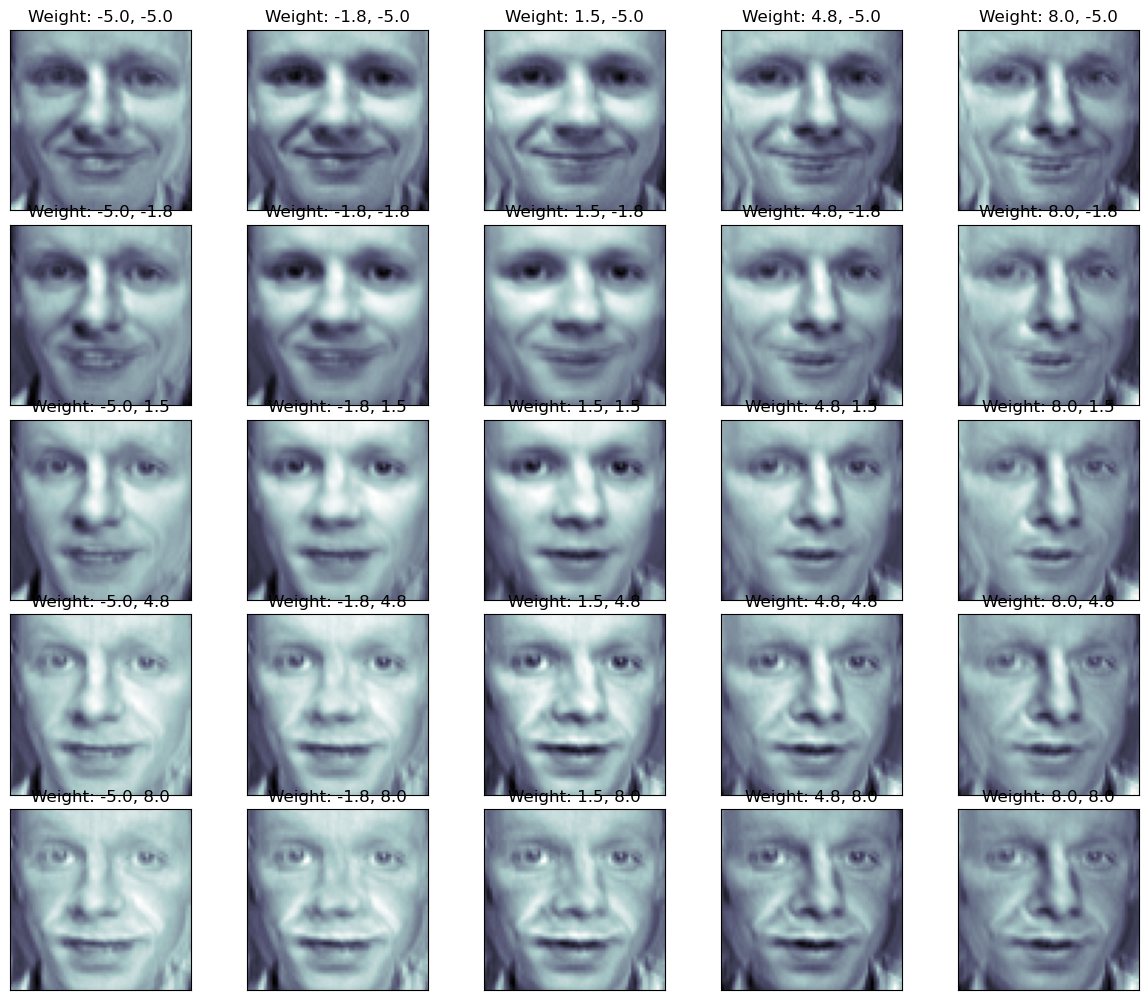

In [23]:
w1 = w1.reshape(-1)
w2 = w2.reshape(-1)

fig = plt.figure(figsize=(12, 10))
plt.subplots_adjust(top=1,
                    bottom=0,
                    hspace=0,
                    wspace=0.05)

n = 5
m = 5
for i in range(n * m):
    ax = fig.add_subplot(n, m, i + 1)
    ax.imshow(face_mean + w1[i] * face_p1 + w2[i] * face_p2, cmap=plt.cm.bone)
    ax.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.title(f'Weight: {round(w1[i], 1)}, {round(w2[i], 1)}')

plt.tight_layout()
plt.show()